Time Series Analysis on :
3. USD to INR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('IMF_USD_INR.csv')
print(df.head())
print(df.info())

         Date    INR
0  1-Dec-1994  31.38
1  2-Dec-1994  31.42
2  5-Dec-1994  31.38
3  6-Dec-1994  31.39
4  7-Dec-1994  31.38
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7642 entries, 0 to 7641
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    7642 non-null   object 
 1   INR     7077 non-null   float64
dtypes: float64(1), object(1)
memory usage: 119.5+ KB
None


In [28]:
df['year'] = pd.to_datetime(df['Date'])
print(df.head())
print(df.info())

                  Date    INR  rollMean  rollStd       year
year                                                       
1994-12-01  1-Dec-1994  31.38       NaN      NaN 1994-12-01
1994-12-02  2-Dec-1994  31.42       NaN      NaN 1994-12-02
1994-12-05  5-Dec-1994  31.38       NaN      NaN 1994-12-05
1994-12-06  6-Dec-1994  31.39       NaN      NaN 1994-12-06
1994-12-07  7-Dec-1994  31.38       NaN      NaN 1994-12-07
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7077 entries, 1994-12-01 to 2024-12-23
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      7077 non-null   object        
 1   INR       7077 non-null   float64       
 2   rollMean  7066 non-null   float64       
 3   rollStd   7066 non-null   float64       
 4   year      7077 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 331.7+ KB
None


In [29]:
df.set_index('year',inplace =True)
print(df.head())
print(df.tail())

                  Date    INR  rollMean  rollStd
year                                            
1994-12-01  1-Dec-1994  31.38       NaN      NaN
1994-12-02  2-Dec-1994  31.42       NaN      NaN
1994-12-05  5-Dec-1994  31.38       NaN      NaN
1994-12-06  6-Dec-1994  31.39       NaN      NaN
1994-12-07  7-Dec-1994  31.38       NaN      NaN
                   Date      INR   rollMean   rollStd
year                                                 
2024-12-17  17-Dec-2024  84.9264  84.760392  0.125736
2024-12-18  18-Dec-2024  84.9370  84.799242  0.096822
2024-12-19  19-Dec-2024  85.0739  84.831967  0.117462
2024-12-20  20-Dec-2024  85.0880  84.865258  0.129138
2024-12-23  23-Dec-2024  85.0713  84.893408  0.134511


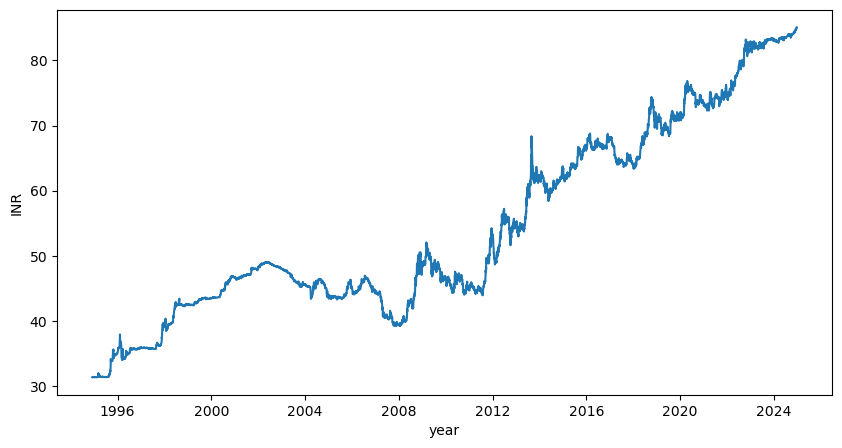

In [30]:
#Visualize
plt.figure(figsize=(10,5))
sns.lineplot(data = df, x=df.index, y=df.INR)
plt.show()

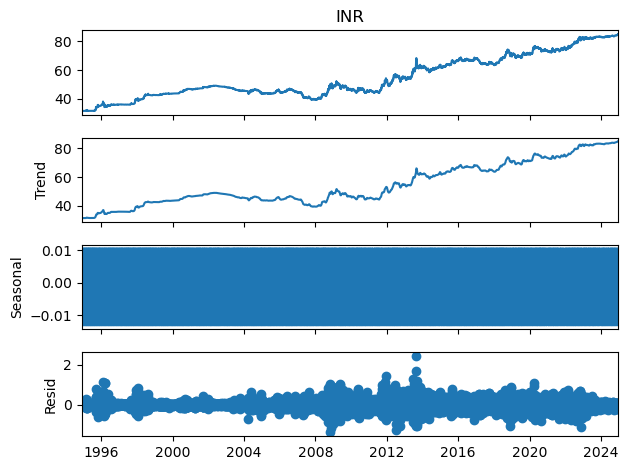

In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df.INR, period =12)
fig =decomposition.plot()
plt.show()

In [32]:
df['rollMean'] = df.INR.rolling(window =12).mean()
df['rollStd'] = df.INR.rolling(window = 12).std()

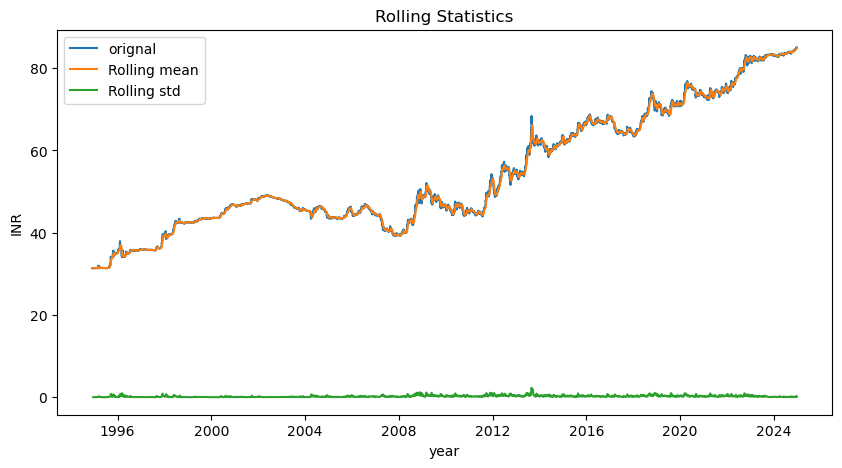

In [33]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x=df.index, y = df.INR, label="orignal")
sns.lineplot(data=df,x=df.index, y = df.rollMean, label="Rolling mean")
sns.lineplot(data=df,x=df.index, y = df.rollStd, label="Rolling std")
plt.title("Rolling Statistics")
plt.show()

ADF p-value: 0.9650
The time series is not stationary (fail to reject H0).


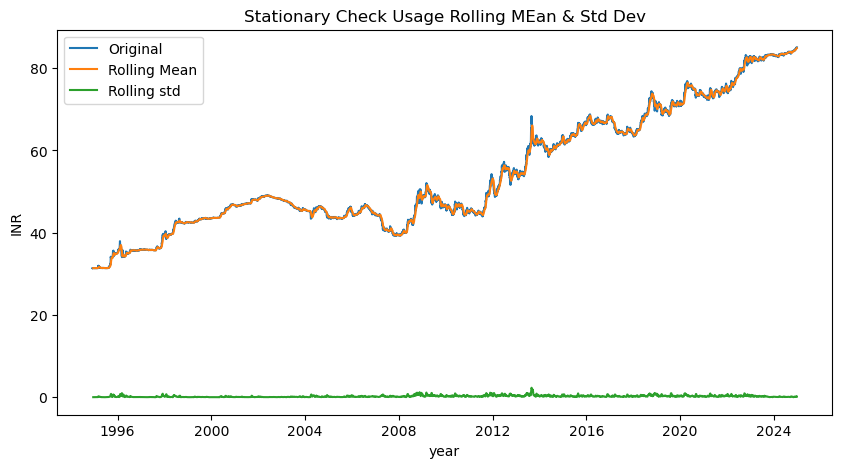

In [34]:
def test_stationary(dataFrame, var):
    dataFrame['rollMean'] = dataFrame[var].rolling(window=12).mean()
    dataFrame['rollStd'] = dataFrame[var].rolling(window=12).std()

    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(dataFrame[var])
    p_value = adf_result[1]

    print(f"ADF p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("The time series is stationary(reject H0).")
    else:
        print("The time series is not stationary (fail to reject H0).")

    #plot
    plt.figure(figsize=(10,5))
    sns.lineplot(data=dataFrame, x=dataFrame.index, y=var, label='Original')
    sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollMean',label='Rolling Mean')
    sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollStd', label='Rolling std')
    plt.title("Stationary Check Usage Rolling MEan & Std Dev")
    plt.legend()
    plt.show()

#calling the function to test functionality
test_stationary(df,'INR')

              INR  shift  shiftDiff
year                               
1994-12-01  31.38    NaN        NaN
1994-12-02  31.42  31.38       0.04
1994-12-05  31.38  31.42      -0.04
1994-12-06  31.39  31.38       0.01
1994-12-07  31.38  31.39      -0.01
1994-12-08  31.38  31.38       0.00
1994-12-09  31.37  31.38      -0.01
1994-12-12  31.37  31.37       0.00
1994-12-13  31.37  31.37       0.00
1994-12-14  31.37  31.37       0.00
1994-12-15  31.37  31.37       0.00
1994-12-16  31.37  31.37       0.00
1994-12-19  31.38  31.37       0.01
1994-12-20  31.40  31.38       0.02
1994-12-21  31.40  31.40       0.00
1994-12-22  31.40  31.40       0.00
1994-12-23  31.40  31.40       0.00
1994-12-27  31.39  31.40      -0.01
1994-12-28  31.43  31.39       0.04
1994-12-29  31.42  31.43      -0.01


C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_18212\122360376.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean'] = dataFrame[var].rolling(window=12).mean()
C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_18212\122360376.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd'] = dataFrame[var].rolling(window=12).std()


ADF p-value: 0.0000
The time series is stationary(reject H0).


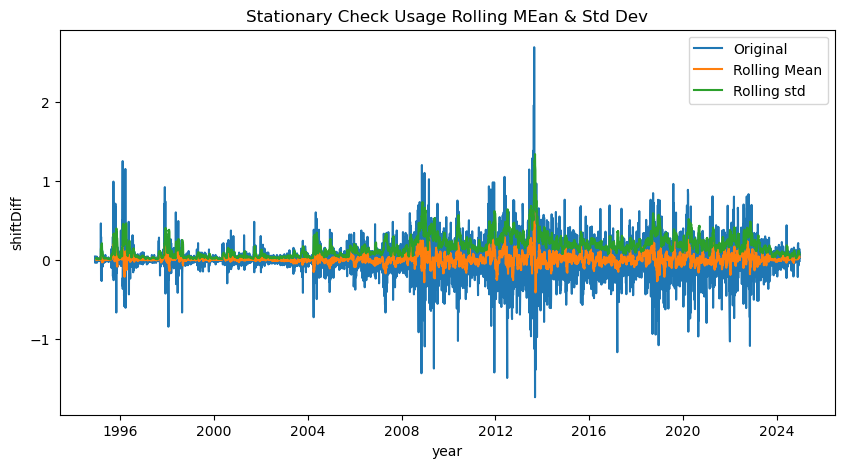

In [10]:
inr_df = df[['INR']].copy()

inr_df['shift'] = inr_df.INR.shift(1)
inr_df['shiftDiff'] = inr_df['INR'] - inr_df['shift']
print(inr_df.head(20))
#Test stationarity
test_stationary(inr_df.dropna(),'shiftDiff')

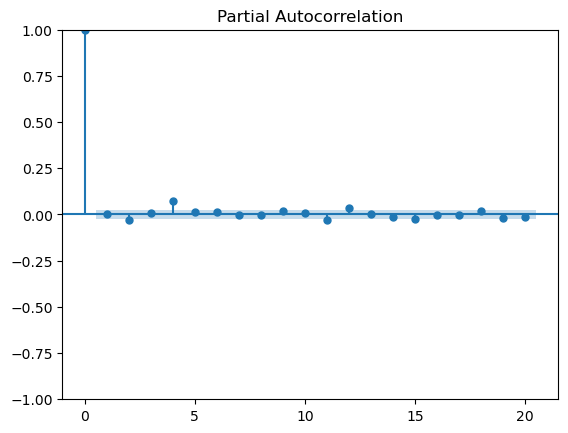

In [35]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_pacf(inr_df['shiftDiff'].dropna(),lags=20)
plt.show()

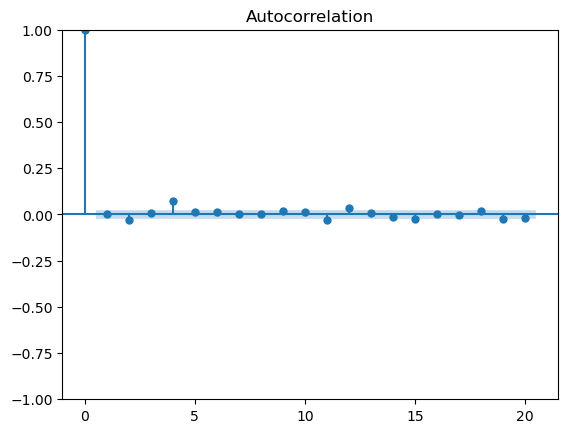

In [36]:
plot_acf(inr_df['shiftDiff'].dropna(), lags =20)
plt.show()

In [37]:
train = inr_df[:round(len(inr_df)*70/100)] 
print(train.head()) 

test = inr_df[round(len(inr_df)*71/100):] 
print(test.head())

model = ARIMA(train['INR'], order =(1,1,1)) 
model_fit =model.fit()
prediction = model_fit.predict(start = test.index[0], end = test.index[-1])
inr_df['arimaPred'] = prediction
print(inr_df.tail())

              INR  shift  shiftDiff
year                               
1994-12-01  31.38    NaN        NaN
1994-12-02  31.42  31.38       0.04
1994-12-05  31.38  31.42      -0.04
1994-12-06  31.39  31.38       0.01
1994-12-07  31.38  31.39      -0.01
                INR    shift  shiftDiff
year                                   
2015-12-04  66.8365  66.7450     0.0915
2015-12-07  66.6263  66.8365    -0.2102
2015-12-08  66.7983  66.6263     0.1720
2015-12-09  66.7500  66.7983    -0.0483
2015-12-10  66.7905  66.7500     0.0405


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


KeyError: 'The `start` argument could not be matched to a location related to the index of the data.'

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train['INR'],order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit()
prediction = model_fit.predict(start=test.index[0], end =test.index[-1])
inr_df['sarimaxPred'] = prediction
print(inr_df.tail())